In [1]:
#imports :)
import pandas as pd
from scipy.stats import f_oneway
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

In [12]:
def ANOVA_F(gene_exp, features, group_list):

  #store results
  anova_results = []

  #Performing ANOVA per gene (row)
  for id, row in gene_exp.iterrows():
        feature_symbol = features[id]

        #values divided by each group
        feature_gvalues = []
        group_means = [] # To store means for each group

        #making a list of all the values per group for ANOVA
        for group_ids in group_list:
            values = row[group_ids].dropna().tolist()
            feature_gvalues.append(values)
            group_means.append(np.mean(values))


        f_statistic, p_value = f_oneway(*feature_gvalues)

        # Calculate average difference between groups
        max_avg_diff = np.nan
        if len(group_means) == 2:
            max_avg_diff = group_means[0] - group_means[1]

        anova_results.append({
              'Symbol': feature_symbol,
              'F_statistic': f_statistic,
              'P_value': p_value,
              'Average_Difference': max_avg_diff # New column
              })

  #results
  anova_df = pd.DataFrame(anova_results)

  ranked_features = anova_df.sort_values(by='F_statistic', ascending=False)#.reset_index(drop=True)

  return ranked_features

In [38]:
def average_list(data, features):

  results = []

  for id, row in data.iterrows():
    average = row.mean()
    stdev = row.std()

    # Calculate 95% Confidence Interval
    sem = stdev / np.sqrt(data.shape[1])
    df = data.shape[1] - 1
    t_value = t.ppf(0.975, df) # For 95% CI (two-tailed)
    margin_of_error = t_value * sem
    lower_ci = round(average - margin_of_error, 3)
    upper_ci = round(average + margin_of_error, 3)


    ci = [lower_ci, upper_ci]

    results.append({
              'Symbol': features[id],
              'Mean': average,
              'Stdev': stdev,
              'CI': ci
              })
  df = pd.DataFrame(results)

  return df

In [29]:
### ANOVA

data = pd.read_csv('/content/data.csv')

#Features & gene expression
features = data['Symbol']
gene_exp = data.drop(columns=['Symbol'])

#Columns for healthy control, long covid & CFS
groups_list = []
for prefix in ['HC', 'LC', 'ME']:
    groups_list.append([col for col in gene_exp.columns if col.startswith(prefix)])

ranked_features = ANOVA_F(gene_exp, features, groups_list)

In [30]:
ranked_features.head(10)

,Symbol,F_statistic,P_value,Average_Difference
407,PIK3R1,12.821825,0.000041,NaN
159,ECHS1,10.192764,0.000230,NaN
546,TNFAIP3,9.744471,0.000314,NaN
509,SOCS3,9.617452,0.000343,NaN
297,JARID2,8.480416,0.000767,NaN
336,MAP3K8,8.358937,0.000838,NaN
310,LAIR1,8.087750,0.001020,NaN
30,BATF,7.829467,0.001233,NaN
600,YES1,7.794794,0.001265,NaN
162,EHHADH,7.383946,0.001717,NaN


In [31]:
### SAVING FEATURES (250 highest f score)

top_250 = ranked_features.sort_values(by='F_statistic', ascending=False).head(250)
data_top_250 = data[data["Symbol"].isin(top_250["Symbol"])]
data_top_250.to_csv('data_top_250.csv', index=False)

In [32]:
### RANKING FEATURES BASED ON CLUSTER // CONTROL GROUP


#df with only HCs
HC_ids = [col for col in gene_exp.columns if col.startswith('HC')]
HCs = data_top_250[['Symbol'] + HC_ids]

features_hc = HCs['Symbol']
gene_exp_hc = HCs.drop('Symbol', axis=1)

#HC in cluster 2 were HC07, HC10, HC13
clus_2 = ['HC07', 'HC10', 'HC13']
clus_1 = list(gene_exp_hc.columns)
clus_1 = [item for item in clus_1 if item not in clus_2]

groups_list_hc = [clus_1, clus_2]

ranked_features_hc = ANOVA_F(gene_exp_hc, features_hc, groups_list_hc)

In [33]:
top_10 = list(ranked_features_hc.head(10).Symbol)
print(top_10)
top_10_df = ranked_features_hc.head(10)
top_10_df.to_csv('top_10_features.csv', index=False)

ranked_features_hc.head(10)

['HLA-DQA1', 'HLA-DQB1', 'CTF1', 'OAS2', 'TRIM46', 'SOCS1', 'RGS16', 'DUSP1', 'ZFP36L2', 'GSK3B']


,Symbol,F_statistic,P_value,Average_Difference
99,HLA-DQA1,380.575236,1.404065e-12,8.233225
100,HLA-DQB1,121.952265,6.790177e-09,7.745414
62,CTF1,8.044328,1.191503e-02,1.186658
154,OAS2,6.516637,2.128369e-02,-0.386360
225,TRIM46,5.841812,2.795720e-02,0.654095
200,SOCS1,5.824074,2.816263e-02,0.672068
186,RGS16,5.622363,3.062524e-02,0.566382
73,DUSP1,5.129707,3.775862e-02,-0.963099
236,ZFP36L2,4.802073,4.356962e-02,0.779811
94,GSK3B,4.594672,4.778434e-02,0.344720


In [41]:
### DESCRIPTIVES

filtered_gene_exp_hc_for_clus1 = gene_exp_hc.loc[features_hc[features_hc.isin(top_10)].index, clus_1]
filtered_features_hc_for_clus1 = features_hc[features_hc.isin(top_10)]

clus_1_desc = average_list(filtered_gene_exp_hc_for_clus1, filtered_features_hc_for_clus1)

filtered_gene_exp_hc_for_clus2 = gene_exp_hc.loc[features_hc[features_hc.isin(top_10)].index, clus_2]
filtered_features_hc_for_clus2 = features_hc[features_hc.isin(top_10)]

clus_2_desc = average_list(filtered_gene_exp_hc_for_clus2, filtered_features_hc_for_clus2)

# Add a distinguishing column to each DataFrame
clus_1_desc['Cluster'] = 'clus1'
clus_2_desc['Cluster'] = 'clus2'

# Merge the two DataFrames
merged_desc = pd.concat([clus_1_desc, clus_2_desc], ignore_index=True)
display(merged_desc)

merged_desc.to_csv('top_10_descriptives.csv', index=False)

,Symbol,Mean,Stdev,CI,Cluster
0,CTF1,4.107528,0.654456,"[3.745, 4.47]",clus1
1,DUSP1,12.174169,0.601705,"[11.841, 12.507]",clus1
2,GSK3B,8.358007,0.266159,"[8.211, 8.505]",clus1
3,HLA-DQA1,10.946932,0.690964,"[10.564, 11.33]",clus1
4,HLA-DQB1,9.731591,1.178072,"[9.079, 10.384]",clus1
5,OAS2,9.528943,0.247982,"[9.392, 9.666]",clus1
6,RGS16,4.626536,0.341604,"[4.437, 4.816]",clus1
7,SOCS1,7.319989,0.411787,"[7.092, 7.548]",clus1
8,TRIM46,4.592141,0.453105,"[4.341, 4.843]",clus1
9,ZFP36L2,10.219251,0.591023,"[9.892, 10.547]",clus1


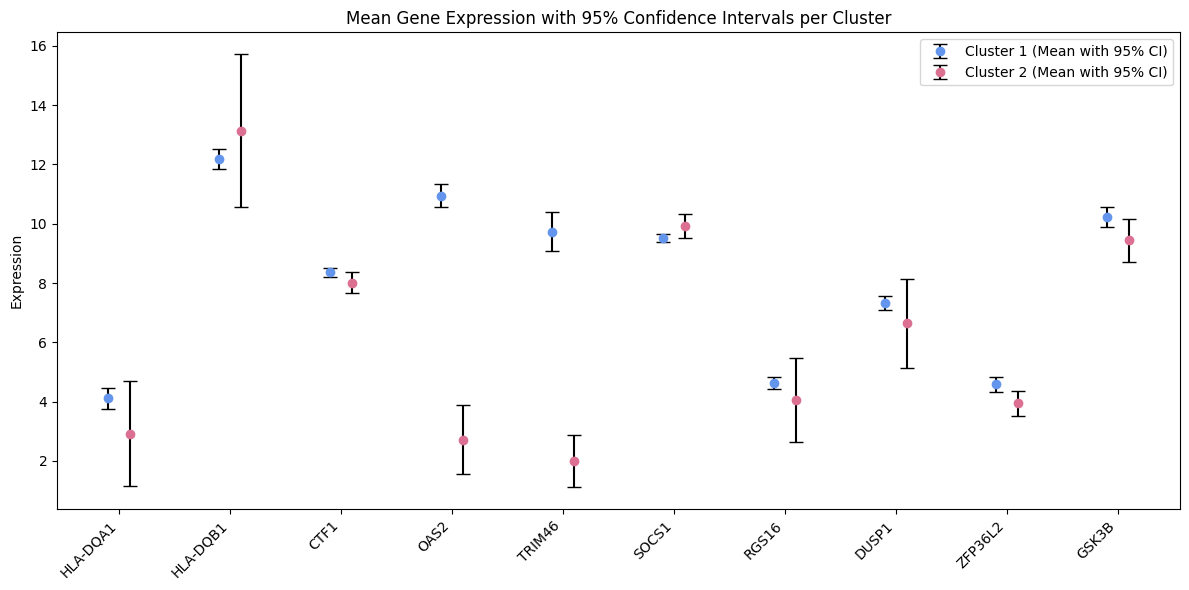

In [20]:
### PLOT WOTH 95% CI AS ERROR BARS

# Set the figure size for a larger plot
plt.figure(figsize=(12, 6))

# width for plotting points, not bars
point_offset = 0.1 # Small offset for points to distinguish groups

# Get means and standard deviations from the dataframes
means1 = clus_1_desc['Mean'].tolist()
stds1 = clus_1_desc['Stdev'].tolist()
means2 = clus_2_desc['Mean'].tolist()
stds2 = clus_2_desc['Stdev'].tolist()

# Sample sizes for each cluster
n1 = len(clus_1)
n2 = len(clus_2)

# Calculate 95% confidence intervals for each feature
yerr_clus1 = []
for i in range(len(means1)):
    sem1 = stds1[i] / np.sqrt(n1)
    df1 = n1 - 1
    # t-value for 95% confidence interval (two-tailed)
    t_value1 = t.ppf(0.975, df1)
    margin_of_error1 = t_value1 * sem1
    yerr_clus1.append(margin_of_error1)

yerr_clus2 = []
for i in range(len(means2)):
    sem2 = stds2[i] / np.sqrt(n2)
    df2 = n2 - 1
    # t-value for 95% confidence interval (two-tailed)
    t_value2 = t.ppf(0.975, df2)
    margin_of_error2 = t_value2 * sem2
    yerr_clus2.append(margin_of_error2)

# The x position for points
r_base = np.arange(len(means1))
r1 = [x - point_offset for x in r_base]
r2 = [x + point_offset for x in r_base]

# Create point plots with error bars for 95% CI
plt.errorbar(r1, means1, yerr=yerr_clus1, fmt='o', color='cornflowerblue',
             ecolor='black', capsize=5, label='Cluster 1 (Mean with 95% CI)')

plt.errorbar(r2, means2, yerr=yerr_clus2, fmt='o', color='palevioletred',
             ecolor='black', capsize=5, label='Cluster 2 (Mean with 95% CI)')

# general layout
plt.xticks(r_base, top_10_df.Symbol, rotation=45, ha='right')
plt.ylabel('Expression')
plt.legend()
plt.title('Mean Gene Expression with 95% Confidence Intervals per Cluster')
plt.tight_layout()

# Show graphic
plt.show()

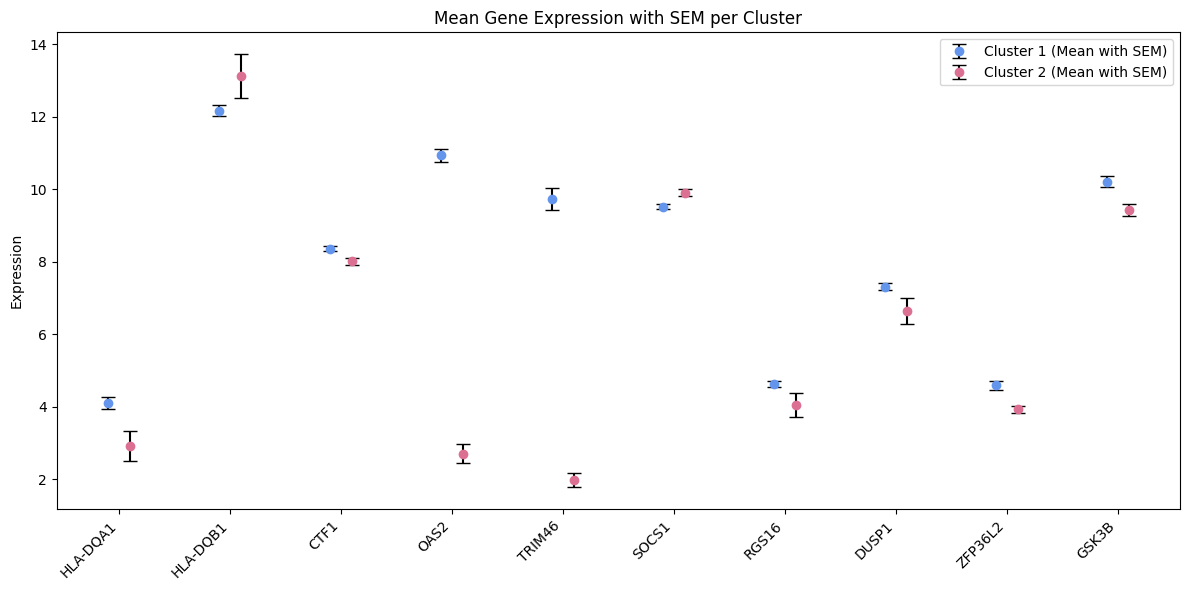

In [21]:
### PLOT WITH SEM INSTEAD OF 95% CI ERROR BARS

# Set the figure size for a larger plot
plt.figure(figsize=(12, 6))

# width for plotting points, not bars
point_offset = 0.1 # Small offset for points to distinguish groups

# Get means and standard deviations from the dataframes
means1 = clus_1_desc['Mean'].tolist()
stds1 = clus_1_desc['Stdev'].tolist()
means2 = clus_2_desc['Mean'].tolist()
stds2 = clus_2_desc['Stdev'].tolist()

# Sample sizes for each cluster
n1 = len(clus_1)
n2 = len(clus_2)

# Calculate SEM for each feature
yerr_clus1 = []
for i in range(len(means1)):
    sem1 = stds1[i] / np.sqrt(n1)
    yerr_clus1.append(sem1)

yerr_clus2 = []
for i in range(len(means2)):
    sem2 = stds2[i] / np.sqrt(n2)
    yerr_clus2.append(sem2)

# The x position for points
r_base = np.arange(len(means1))
r1 = [x - point_offset for x in r_base]
r2 = [x + point_offset for x in r_base]

# Create point plots with error bars for SEM
plt.errorbar(r1, means1, yerr=yerr_clus1, fmt='o', color='cornflowerblue',
             ecolor='black', capsize=5, label='Cluster 1 (Mean with SEM)')

plt.errorbar(r2, means2, yerr=yerr_clus2, fmt='o', color='palevioletred',
             ecolor='black', capsize=5, label='Cluster 2 (Mean with SEM)')

# general layout
plt.xticks(r_base, top_10_df.Symbol, rotation=45, ha='right')
plt.ylabel('Expression')
plt.legend()
plt.title('Mean Gene Expression with SEM per Cluster')
plt.tight_layout()

# Show graphic
plt.show()

In [45]:
### CREATING NEW FILE WITH ONLY CLUSTER 1 AND CLUSTER 2

clus_2_members = ['HC07', 'HC10', 'HC13', 'LC03', 'LC05', 'LC06', 'LC07', 'LC09', 'LC10', 'LC11', 'LC12', 'LC14', 'ME02', 'ME04', 'ME06', 'ME10', 'ME11', 'ME13', 'ME14']

all_sample_columns = data.drop('Symbol', axis=1).columns

clus_1_members = [col for col in all_sample_columns if col not in clus_2_members]


# Create a dictionary for renaming columns
rename_mapping = {}
c1_count = 1
c2_count = 1

for col in all_sample_columns:
    if col in clus_1_members:
        rename_mapping[col] = f'C1_{c1_count:02d}'
        c1_count += 1
    elif col in clus_2_members:
        rename_mapping[col] = f'C2_{c2_count:02d}'
        c2_count += 1

# Apply renaming to a copy of the original data DataFrame
data_by_cluster = data.rename(columns=rename_mapping)

# Display the head of the new DataFrame
display(data_by_cluster.head())
print(data_by_cluster.shape)

data_by_cluster.to_csv('data_by_cluster.csv', index=False)

DataFrame with columns relabeled by cluster:


,Symbol,C1_01,C1_02,C1_03,C1_04,C1_05,C1_06,C2_01,C1_07,C1_08,...,C1_23,C2_16,C1_24,C2_17,C1_25,C1_26,C1_27,C2_18,C2_19,C1_28
0,ACACA,5.053499,5.617595,5.848363,6.001664,4.677177,4.142635,4.909481,4.194121,4.288927,...,5.355035,4.488420,5.200545,5.490907,5.265387,5.604202,5.631611,5.934477,5.471953,6.150710
1,ACADVL,10.458968,10.429012,10.322069,10.490164,10.258972,10.000616,10.117820,10.314544,10.075197,...,10.225797,10.920086,10.654003,10.375338,10.445093,10.407982,10.295039,10.741116,9.694346,10.321545
2,ACAT2,8.147475,8.186651,8.152144,8.590211,8.029162,4.142635,8.342440,8.779083,8.271921,...,8.037463,7.567647,7.629857,8.482083,8.193709,8.435839,8.350874,8.397547,8.575047,8.234310
3,ACSL3,6.522984,6.498950,6.492219,6.085322,5.821567,7.142635,5.734394,6.001476,5.498381,...,5.610292,6.302408,6.044894,6.323179,6.008229,6.174809,6.340148,6.408408,7.232766,5.976680
4,ACSL4,8.581878,8.576681,8.655718,8.793556,8.896855,6.557673,8.480638,8.066246,9.020246,...,8.252588,8.748543,8.888319,8.009872,8.810548,8.872287,8.881389,9.526103,8.928954,8.044425


(635, 48)
